# 11 — Trade Management

## Concept
The baseline OB strategy uses static SL and TP.
Professional trade management can improve expectancy by:

1. **Break-even move**: After price moves 1R in our favour, move SL to entry.
   Converts losses to break-even on retracements.

2. **Partial take profits**: Take 50% at 1R, let remaining run to 2R.
   Locks in profits while keeping exposure to large moves.

3. **ATR trailing stop**: Trail SL by 1× ATR below price (for longs).
   Captures extended trends beyond the fixed TP.

4. **Time-based exit**: Exit if trade hasn't hit TP in N bars.
   Prevents capital from being tied up in dead trades.

## What we test here
Compare static TP/SL vs each management technique on the XAUUSDT M5 OB backtest.

## Important note
These are simulation-only in the backtest. Bybit supports:
- SL/TP modification via API (move to break-even)
- Partial position close (take profit on part of qty)
- The current OrderManager supports amend_conditional_order() for this

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from strategy.ob_core import list_ob_signals, add_candle_features

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (18, 7)})

SYMBOL    = 'XAUUSDT'
RISK_USDT = 20.0
RR        = 2.0

m5 = pd.read_csv(f'../notebooks/data/{SYMBOL}/M5/ohlcv.csv', index_col=0, parse_dates=True)
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
m5 = add_candle_features(m5.sort_index())

signals = list_ob_signals(m5, risk_cash=RISK_USDT, rr=RR)
print(f'Loaded {len(signals)} OB signals for trade management research')

Loaded 290 OB signals for trade management research


In [ ]:
# ── Trade simulation engine ─────────────────────────────────────────────────
FEE_RATE = 0.00055  # 0.055% per side (entry + exit)

def simulate_trades(
    m5_df,
    signals_df,
    management: str = 'static',  # 'static' | 'break_even' | 'partial' | 'trailing'
    start_balance: float = 10000.0,
    risk_usdt: float = 20.0,
    rr: float = 2.0,
    be_trigger_r: float = 1.0,   # move to BE after Nx risk distance
    partial_r: float = 1.0,      # take 50% at this R multiple
    trail_atr_mult: float = 1.0, # trail SL by N × ATR below price
    max_bars: int = 200,         # max holding bars before time exit
):
    trades = []
    balance = start_balance
    eq_curve = [(m5_df.index[0], balance)]

    for _, sig in signals_df.iterrows():
        entry_bar  = int(sig['signal_bar_index'])
        side       = sig['side']
        entry      = float(sig['entry'])
        sl_orig    = float(sig['sl'])
        tp_orig    = float(sig['tp'])
        risk_dist  = abs(entry - sl_orig)
        qty        = risk_usdt / max(risk_dist, 1e-9)
        qty_orig   = qty  # track original qty for entry fee

        sl         = sl_orig
        tp         = tp_orig
        partial_taken = False
        result     = None
        exit_price = None
        exit_time  = None

        # Entry fee charged once on the full position
        entry_fee = entry * qty_orig * FEE_RATE

        for j in range(entry_bar + 1, min(entry_bar + max_bars, len(m5_df))):
            bar = m5_df.iloc[j]
            high, low, close = float(bar['high']), float(bar['low']), float(bar['close'])
            atr = float(bar.get('atr', risk_dist))

            # ── Break-even management ─────────────────────────────────────
            if management in ('break_even', 'partial'):
                be_level = entry + be_trigger_r * risk_dist if side == 'buy' else entry - be_trigger_r * risk_dist
                if side == 'buy' and close >= be_level and sl < entry:
                    sl = entry  # move SL to entry
                elif side == 'sell' and close <= be_level and sl > entry:
                    sl = entry

            # ── Partial take profit ───────────────────────────────────────
            if management == 'partial' and not partial_taken:
                partial_tp = entry + partial_r * risk_dist if side == 'buy' else entry - partial_r * risk_dist
                if (side == 'buy' and high >= partial_tp) or (side == 'sell' and low <= partial_tp):
                    # Take 50% profit (fee charged on this partial exit)
                    fee_partial = partial_tp * (qty * 0.5) * FEE_RATE
                    pnl_partial = partial_r * risk_dist * (qty * 0.5) - fee_partial
                    balance += pnl_partial
                    qty *= 0.5
                    partial_taken = True

            # ── Trailing stop ─────────────────────────────────────────────
            if management == 'trailing':
                if side == 'buy':
                    trail_sl = close - trail_atr_mult * atr
                    if trail_sl > sl:
                        sl = trail_sl
                else:
                    trail_sl = close + trail_atr_mult * atr
                    if trail_sl < sl:
                        sl = trail_sl

            # ── Exit conditions ──────────────────────────────────────────
            hit_sl = low <= sl if side == 'buy' else high >= sl
            hit_tp = high >= tp if side == 'buy' else low <= tp

            if hit_sl or hit_tp:
                exit_price = sl if hit_sl else tp
                result = 'loss' if hit_sl else 'win'
                exit_time = m5_df.index[j]
                break

        if result is None:
            # Time exit
            exit_price = float(m5_df.iloc[min(entry_bar + max_bars, len(m5_df)-1)]['close'])
            result = 'time_exit'
            exit_time = m5_df.index[min(entry_bar + max_bars, len(m5_df)-1)]

        # Exit fee on remaining qty + entry fee (not yet deducted)
        exit_fee = exit_price * qty * FEE_RATE
        pnl = ((exit_price - entry) * qty if side == 'buy' else (entry - exit_price) * qty) - entry_fee - exit_fee
        balance += pnl
        eq_curve.append((exit_time, balance))

        trades.append({
            'result': result, 'pnl': pnl, 'balance': balance, 'side': side,
            'entry': entry, 'exit': exit_price, 'exit_time': exit_time,
        })

    return pd.DataFrame(trades), pd.Series({t: v for t, v in eq_curve})


print('Simulation engine ready. Running 4 strategies...')

In [3]:
# ── Run all 4 management styles ────────────────────────────────────────────
results = {}
equities = {}

for style in ['static', 'break_even', 'partial', 'trailing']:
    trades, eq = simulate_trades(m5, signals, management=style)
    results[style] = trades
    equities[style] = eq

    if not trades.empty:
        win_rate = (trades['result'] == 'win').mean()
        total_pnl = trades['pnl'].sum()
        wins = trades[trades['result']=='win']['pnl']
        losses = trades[trades['result']=='loss']['pnl']
        pf = wins.sum() / abs(losses.sum()) if len(losses) > 0 and losses.sum() != 0 else 0
        print(f'{style:15s}: trades={len(trades)} win={win_rate*100:.1f}% PnL={total_pnl:.0f} PF={pf:.2f}')

static         : trades=290 win=50.3% PnL=3121 PF=2.10
break_even     : trades=290 win=40.0% PnL=2421 PF=2.04
partial        : trades=290 win=40.0% PnL=244 PF=1.09
trailing       : trades=290 win=10.0% PnL=799 PF=3.21


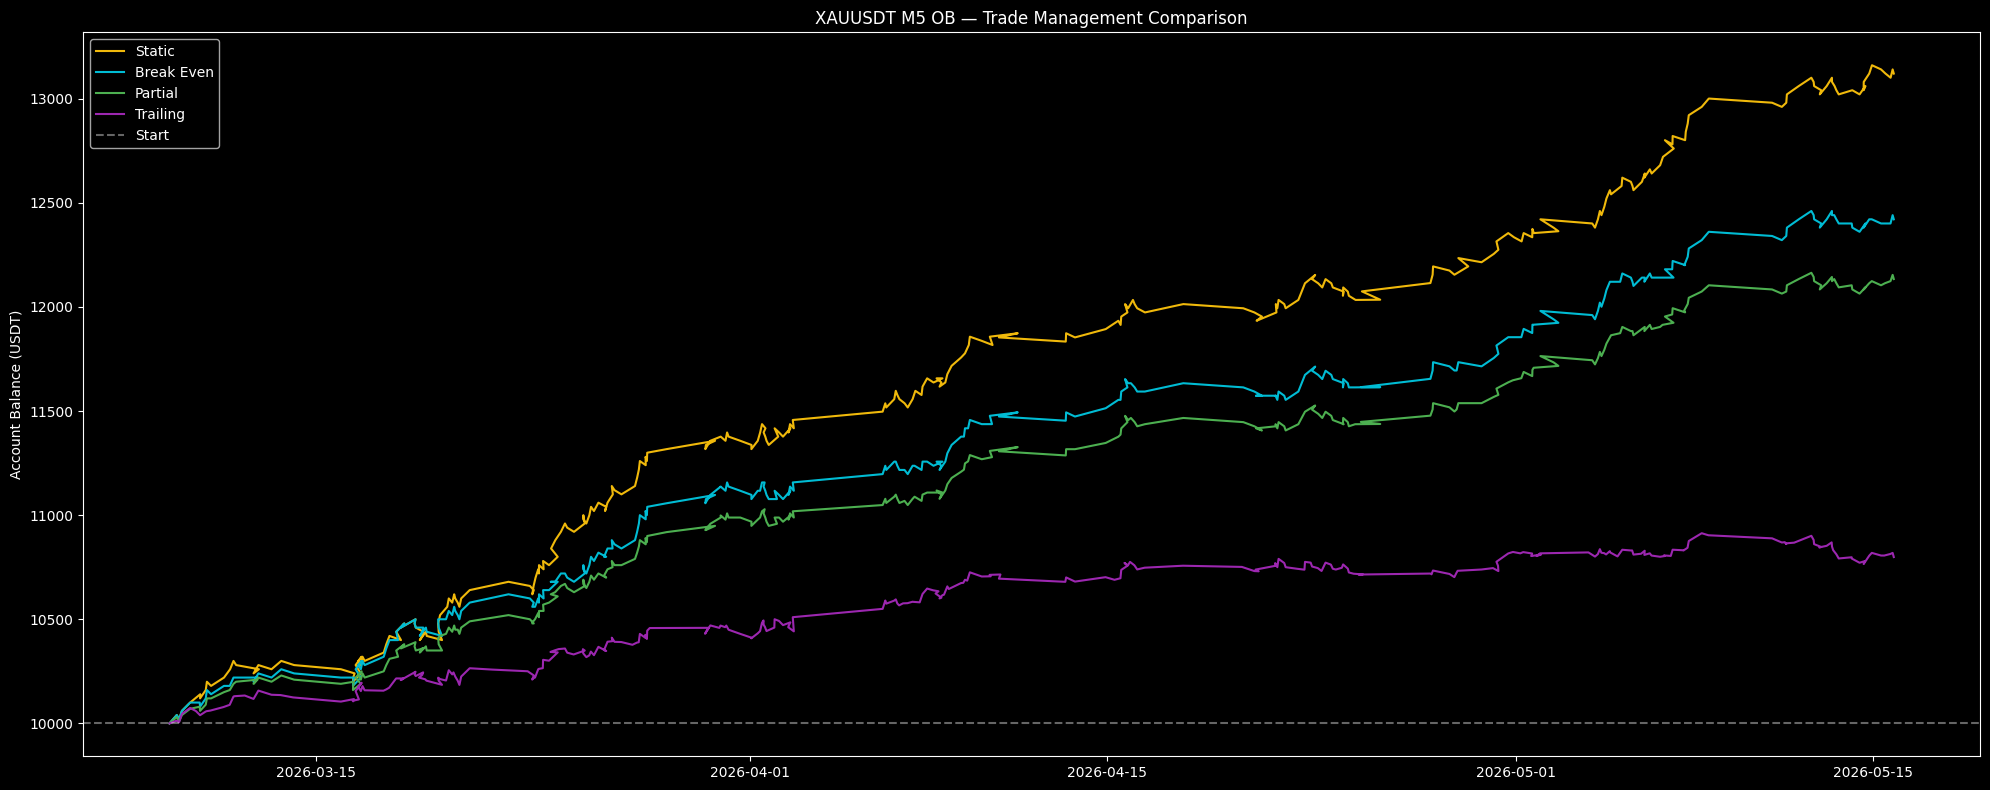


Conclusion: Use the management style that improves expectancy on YOUR data.
Break-even is lowest risk. Trailing stop captures extended trends.


In [4]:
# ── Compare equity curves ─────────────────────────────────────────────────
colors = ['#F0B90B', '#00BCD4', '#4CAF50', '#9C27B0']
fig, ax = plt.subplots(figsize=(20, 8))

for (style, eq), color in zip(equities.items(), colors):
    ax.plot(eq.index, eq.values, label=style.replace('_', ' ').title(),
            color=color, linewidth=1.5)

ax.axhline(10000, color='white', linestyle='--', alpha=0.4, label='Start')
ax.set_title(f'{SYMBOL} M5 OB — Trade Management Comparison')
ax.set_ylabel('Account Balance (USDT)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nConclusion: Use the management style that improves expectancy on YOUR data.')
print('Break-even is lowest risk. Trailing stop captures extended trends.')